In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1)

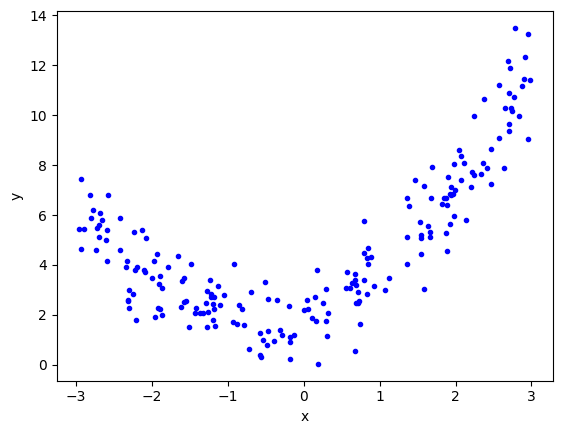

In [4]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Let's test linear regression on this data

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [6]:
lr = LinearRegression()

In [7]:
lr.fit(x_train,y_train)

LinearRegression()

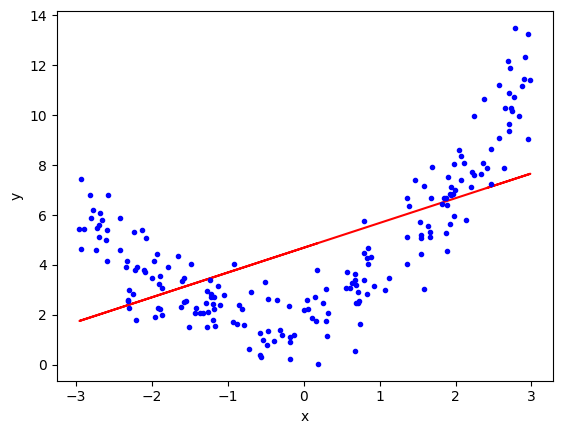

In [8]:
plt.plot(x_train,lr.predict(x_train),color = 'red')
plt.plot(x,y, 'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [9]:
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.48528076818210375

# Now applying polynomial linear regression
# degree 2

In [10]:
plr = PolynomialFeatures(degree = 2)

In [11]:
x_train_trans = plr.fit_transform(x_train)
x_test_trans = plr.transform(x_test)

In [12]:
print(x_train[0])
print(x_train_trans[0])

[0.18235559]
[1.         0.18235559 0.03325356]


**the above line has x_train and x_train_trans which shows x and x^0 x^1 x^2 respectively**

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(x_train_trans,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.7764848481385177

In [16]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91083502 0.82342281]]
[2.05960489]


In [17]:
x_new = np.linspace(-3,3,200).reshape(200, 1)
x_new_poly = plr.transform(x_new)
y_new = lr.predict(x_new_poly)

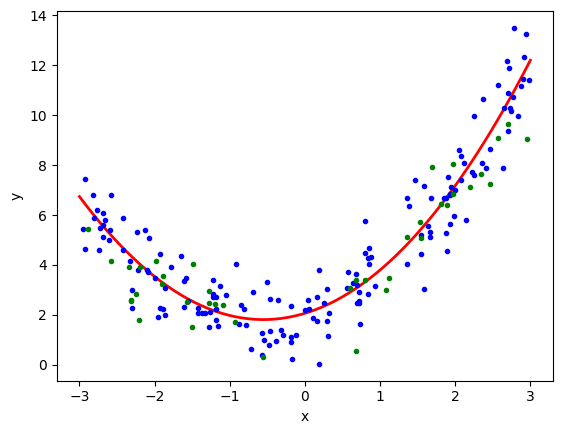

In [18]:
plt.plot(x_new,y_new,color = 'red',linewidth = 2,label = 'predictions')
plt.plot(x_train,y_train,'b.',label = 'Training points')
plt.plot(x_test,y_test,'g.',label ='Testing points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Now applying 3D polynomial regression

In [19]:
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8 

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)
#z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [20]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x = x.ravel(), y = y.ravel(), z = z.ravel())
fig.show()

# Now let's apply multiple linear regression on polynomial data


In [21]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [22]:
import plotly.graph_objects as go
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x =x_input, y = y_input, z= z_final ))
fig.show()

# Now let's apply polynomial linear regression

In [23]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [24]:
poly = PolynomialFeatures(degree = 5)
x_multi_trans = poly.fit_transform(x_multi)

In [25]:
x_multi_trans.shape

(100, 21)

In [26]:
lr = LinearRegression()
lr.fit(x_multi_trans,z)

LinearRegression()

In [27]:
x_test_multi = poly.transform(final)

In [28]:
z_final = lr.predict(x_multi_trans).reshape(10,10)

In [29]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.update_layout(scene = dict(zaxis = dict(range = [0,35])))
fig.show()